# Olive Atlas consolidated analysis for manuscript

This notebook replaces the previous two notebooks and resolves the **120 vs 60** issue.

**Data logic**

- The raw CSV contains **120 side-level observations**: 20 rows × 3 longitudinal sections × 2 canopy faces.
- The manuscript should use **60 subsection-level observations**: 20 rows × 3 sections, after combining the two canopy faces.
- This is the correct unit for the paper because production is available/validated after both canopy faces are combined.

The notebook exports the figures used by the LaTeX manuscript and prints manuscript-ready statistics.


In [1]:
# Core packages
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / 'Atlas_data.csv'
FIG_DIR = BASE_DIR / 'figures'
TAB_DIR = BASE_DIR / 'tables'
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams['figure.dpi'] = 150
# Use same palette as analysis.ipynb for consistent figures
PALETTE = sns.color_palette('deep')


## 1. Load raw side-level data

Place `Elaborate_Roberto_light.csv` in the same folder as this notebook.

Expected raw unit: **one canopy face of one row-section**. Therefore the raw file should have 120 rows.


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(f'Missing {DATA_FILE.name}. Put it in the same folder as this notebook.')

raw = pd.read_csv(DATA_FILE, sep=';', decimal=',', header=0)
raw.columns = [c.strip() for c in raw.columns]

# Standardise maturity-index column names from the existing files.
rename_map = {
    'M.I. NORM': 'MI_Garcia',
    'M.I. Garcia': 'MI_Garcia',
    'M.I. visivo': 'MI_Visual',
    'Produzione plot [kg]': 'Atlas_production_side_kg',
    'Produzione plot somma dei due lati [kg]': 'Atlas_production_both_faces_kg',
    'Produzione plot MISURATA': 'Measured_production_kg',
}
raw = raw.rename(columns={k:v for k,v in rename_map.items() if k in raw.columns})

print('Raw side-level dataset shape:', raw.shape)
print('Columns:')
print(list(raw.columns))
raw.head()


Raw side-level dataset shape: (120, 19)
Columns:
['Plot', 'frutti/pianta', 'N. frutti', 'Superficie plot [ha]', 'Atlas_production_side_kg', 'Resa [kg/ha]', 'Atlas_production_both_faces_kg', 'Resa somma dei due lati [kg/ha]', 'Measured_production_kg', 'Color Index', 'CL 0', 'CL 1', 'CL 2', 'CL 3', 'CL 4', 'MI_Garcia', 'MI_Garcia', 'MI_Visual', 'Color Index.1']


,Plot,frutti/pianta,N. frutti,Superficie plot [ha],Atlas_production_side_kg,Resa [kg/ha],Atlas_production_both_faces_kg,Resa somma dei due lati [kg/ha],Measured_production_kg,Color Index,CL 0,CL 1,CL 2,CL 3,CL 4,MI_Garcia,MI_Garcia,MI_Visual,Color Index.1
0,01-01,1910,74353,0.02,132.3,6617.4,269.74476,13487.238,715.74476,0.62,47,73,30,24,0,2.05,1.18,1.91,0.62
1,01-02,1982,77189,0.02,137.4,6869.8,NaN,NaN,NaN,0.67,46,49,26,42,0,2.27,1.39,2.03,0.67
2,01-03,1320,51392,0.02,91.5,4573.9,177.37522,8868.761,541.37522,0.78,17,38,29,84,0,3.48,2.07,2.31,0.78
3,01-04,1246,48257,0.02,85.9,4294.9,NaN,NaN,NaN,0.85,12,20,34,101,0,3.91,2.34,2.31,0.85
4,01-05,1324,51553,0.02,91.8,4588.2,185.25172,9262.586,645.25172,0.78,28,28,22,85,0,3.27,2.01,2.21,0.78


## 2. Resolve the 120 vs 60 issue

The old correlation notebook used the raw 120 side-level observations. The production notebook used 60 observations because it combined both faces of each row-section.

For publication, the analysis below aggregates every two consecutive side observations into one **subsection-level** observation. This assumes the CSV is ordered as paired faces:

`face A subsection 1`, `face B subsection 1`, `face A subsection 2`, `face B subsection 2`, ...

If your CSV is not ordered this way, add an explicit subsection identifier and replace `subsection_id = raw.index // 2` with that identifier.


In [3]:
# Basic validation
if len(raw) % 2 != 0:
    raise ValueError('The raw file has an odd number of rows; cannot aggregate paired canopy faces by consecutive pairs.')

raw = raw.reset_index(drop=True).copy()
raw['subsection_id'] = raw.index // 2 + 1
raw['face_in_pair'] = np.where(raw.index % 2 == 0, 'A', 'B')

print('Side-level observations:', len(raw))
print('Subsection-level observations after pairing faces:', raw['subsection_id'].nunique())
print(raw[['subsection_id','face_in_pair'] + (["Plot"] if 'Plot' in raw.columns else [])].head(8))


Side-level observations: 120
Subsection-level observations after pairing faces: 60
   subsection_id face_in_pair   Plot
0              1            A  01-01
1              1            B  01-02
2              2            A  01-03
3              2            B  01-04
4              3            A  01-05
5              3            B  01-06
6              4            A  01-07
7              4            B  01-08


## 3. Aggregate both faces into 60 subsection-level observations

Aggregation rules:

- `CL 0`--`CL 4`: summed across the two faces.
- `MI_Garcia`: recalculated from summed Atlas class counts.
- `Color Index`: fruit-count-weighted mean where possible.
- `MI_Visual`: mean of the two face-level visual MI values, unless your manual protocol has raw visual class counts. If visual class counts are available later, recompute Visual MI from those counts.
- Atlas production: uses the precomputed both-face value when present; otherwise sums the two side-level Atlas production values.
- Measured production: first non-missing value in the paired faces.


In [4]:
CL_COLS = ['CL 0','CL 1','CL 2','CL 3','CL 4']
for col in CL_COLS:
    if col not in raw.columns:
        raise KeyError(f'Missing expected class-count column: {col}')

# Helper for first non-null value within a pair.
def first_valid(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

agg = pd.DataFrame({'subsection_id': sorted(raw['subsection_id'].unique())})

g = raw.groupby('subsection_id', sort=True)

# Keep useful labels if available.
if 'Plot' in raw.columns:
    agg['source_plot_pair'] = g['Plot'].agg(lambda x: ' + '.join(map(str, x))) .values

# Sum class counts across faces.
for col in CL_COLS:
    agg[col] = g[col].sum().values

class_weights = np.array([0,1,2,3,4], dtype=float)
class_matrix = agg[CL_COLS].values.astype(float)
agg['Atlas_detected_olives'] = class_matrix.sum(axis=1)
agg['MI_Garcia'] = (class_matrix @ class_weights) / agg['Atlas_detected_olives'].replace(0, np.nan)

# Visual MI: average side values, unless you later add raw visual class counts.
if 'MI_Visual' in raw.columns:
    agg['MI_Visual'] = g['MI_Visual'].mean().values

# Color Index: weighted by detected olives when possible; otherwise simple mean.
if 'Color Index' in raw.columns:
    tmp = raw.copy()
    tmp['detected_side'] = tmp[CL_COLS].sum(axis=1)
    def weighted_ci(sub):
        w = sub['detected_side'].to_numpy(dtype=float)
        x = sub['Color Index'].to_numpy(dtype=float)
        ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
        if ok.sum() == 0:
            return np.nanmean(x)
        return np.average(x[ok], weights=w[ok])
    agg['Color_Index'] = tmp.groupby('subsection_id').apply(weighted_ci).values

# Atlas production: prefer the precomputed both-face value; otherwise sum side-level production.
if 'Atlas_production_both_faces_kg' in raw.columns:
    agg['Atlas_estimated_production_kg'] = g['Atlas_production_both_faces_kg'].agg(first_valid).values
elif 'Atlas_production_side_kg' in raw.columns:
    agg['Atlas_estimated_production_kg'] = g['Atlas_production_side_kg'].sum().values

# Measured production: usually available once per pair.
if 'Measured_production_kg' in raw.columns:
    agg['Measured_production_kg'] = g['Measured_production_kg'].agg(first_valid).values

print('Aggregated subsection-level dataset shape:', agg.shape)
print(agg.head())

agg.to_csv(TAB_DIR / 'olive_atlas_aggregated_60_subsections.csv', index=False)
print('Saved:', TAB_DIR / 'olive_atlas_aggregated_60_subsections.csv')


Aggregated subsection-level dataset shape: (60, 13)
   subsection_id source_plot_pair  CL 0  CL 1  CL 2  CL 3  CL 4  \
0              1    01-01 + 01-02    93   122    56    66     0   
1              2    01-03 + 01-04    29    58    63   185     0   
2              3    01-05 + 01-06    49    65    58   146     0   
3              4    01-07 + 01-08    46    53    65   163     0   
4              5    01-09 + 01-10    38    73    77   130     0   

   Atlas_detected_olives  MI_Garcia  MI_Visual  Color_Index  \
0                  337.0   1.281899      1.970     0.644184   
1                  335.0   2.205970      2.310     0.814896   
2                  318.0   1.946541      2.200     0.770252   
3                  327.0   2.055046      2.355     0.819878   
4                  318.0   1.940252      2.300     0.780000   

   Atlas_estimated_production_kg  Measured_production_kg  
0                      269.74476               715.74476  
1                      177.37522               5

## 4. Descriptive statistics and ripening-class distribution


Ripening class distribution after aggregating both faces (n=60 subsections):
class  count percent
 CL 0    974     5.4
 CL 1   1957    10.9
 CL 2   3852    21.5
 CL 3  11167    62.2
 CL 4      0     0.0
Total Atlas-detected olives: 17950


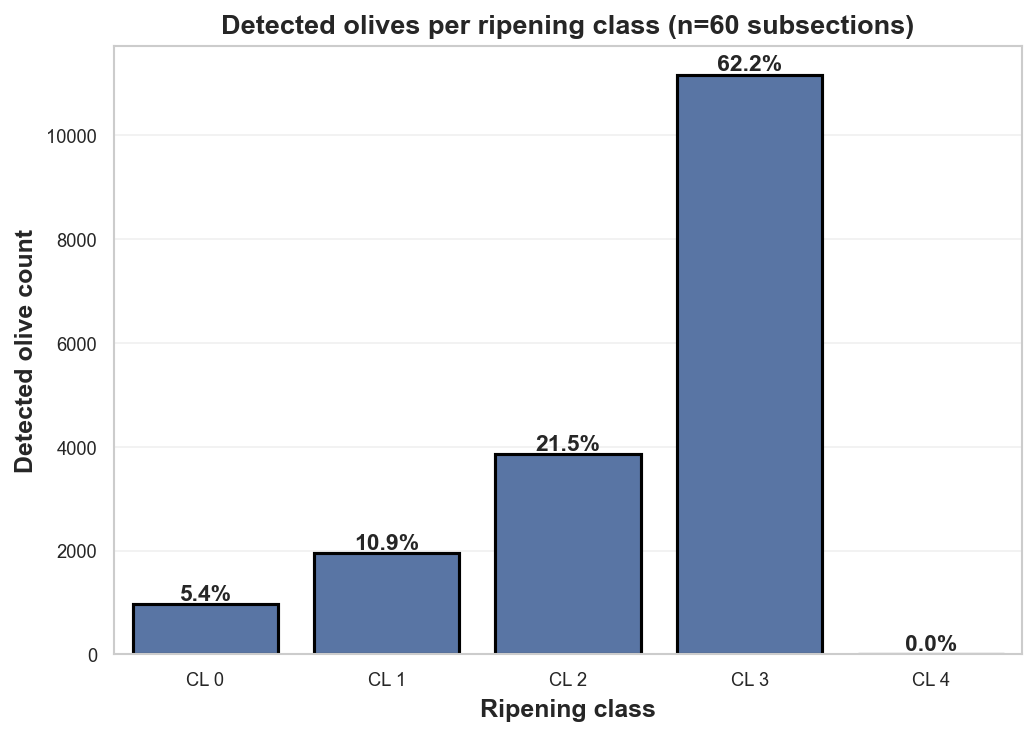

In [5]:
# Class totals based on the aggregated 60-subsection dataset.
class_totals = agg[CL_COLS].sum()
class_pct = class_totals / class_totals.sum() * 100
class_summary = pd.DataFrame({'class': CL_COLS, 'count': class_totals.values.astype(int), 'percent': class_pct.values})
class_summary.to_csv(TAB_DIR / 'ripening_class_distribution.csv', index=False)

print('Ripening class distribution after aggregating both faces (n=60 subsections):')
print(class_summary.to_string(index=False, formatters={'percent': '{:.1f}'.format}))
print('Total Atlas-detected olives:', int(class_totals.sum()))

# Use Seaborn barplot for consistent styling
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='class', y='count', data=class_summary, palette=[PALETTE[0]]*len(class_summary), ax=ax, edgecolor='black', linewidth=1.5)
for i, row in class_summary.iterrows():
    ax.text(i, row['count'], f"{row['percent']:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Ripening class', fontsize=12, fontweight='bold')
ax.set_ylabel('Detected olive count', fontsize=12, fontweight='bold')
ax.set_title('Detected olives per ripening class (n=60 subsections)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(FIG_DIR / 'corr_fig4_olive_count_per_class.pdf', dpi=300, bbox_inches='tight')
plt.show()


## 5. Correlation matrix on the 60 subsection-level dataset


Correlation dataset n = 60
MI_Garcia vs MI_Visual: r=0.9219, p=1.479e-25
MI_Garcia vs Color_Index: r=0.9696, p=3.714e-37
MI_Visual vs Color_Index: r=0.9659, p=9.899e-36


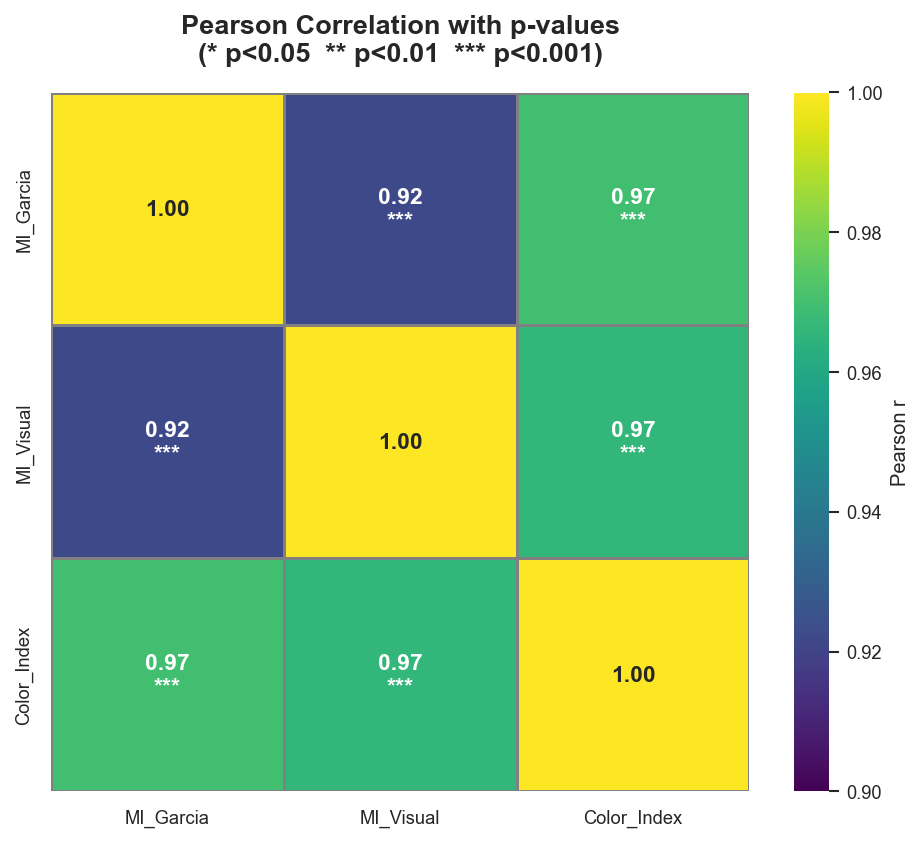

In [6]:
corr_vars = [c for c in ['MI_Garcia','MI_Visual','Color_Index'] if c in agg.columns]
if len(corr_vars) < 2:
    raise ValueError('Not enough variables available for correlation analysis.')

data_corr = agg[corr_vars].dropna()
print('Correlation dataset n =', len(data_corr))

r_mat = pd.DataFrame(np.eye(len(corr_vars)), index=corr_vars, columns=corr_vars)
p_mat = pd.DataFrame(np.zeros((len(corr_vars), len(corr_vars))), index=corr_vars, columns=corr_vars)

for i,a in enumerate(corr_vars):
    for j,b in enumerate(corr_vars):
        if i < j:
            r,p = stats.pearsonr(data_corr[a], data_corr[b])
            r_mat.loc[a,b] = r_mat.loc[b,a] = r
            p_mat.loc[a,b] = p_mat.loc[b,a] = p
            print(f'{a} vs {b}: r={r:.4f}, p={p:.3e}')

# Plot annotated matrix.
def star(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

annot = r_mat.copy().astype(str)
for a in corr_vars:
    for b in corr_vars:
        if a == b:
            annot.loc[a,b] = '1.00'
        else:
            annot.loc[a,b] = f"{r_mat.loc[a,b]:.2f}\n{star(p_mat.loc[a,b])}"

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    r_mat.astype(float),
    annot=annot,
    fmt='',
    center=0.95,
    vmin=0.9,
    vmax=1.0,
    square=True,
    cbar_kws={'label':'Pearson r', 'ticks':[0.90, 0.92, 0.94, 0.96, 0.98, 1.00]},
    cmap='viridis',
    ax=ax,
    annot_kws={"size": 11, "weight": "bold"},
    linewidths=0.5,
    linecolor='gray'
)
ax.set_title("Pearson Correlation with p-values\n(* p<0.05  ** p<0.01  *** p<0.001)", 
             fontsize=13, fontweight="bold", pad=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'corr_fig1_correlation_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()


## 6. Helper functions for regression, cross-validation and Bland--Altman


In [7]:
def regression_with_cv(df, x_col, y_col, k=5, random_state=42):
    d = df[[x_col, y_col]].dropna().copy()
    X = d[[x_col]].values
    y = d[y_col].values
    model = LinearRegression().fit(X, y)
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = mean_squared_error(y, pred, squared=False)
    r, p = stats.pearsonr(d[x_col], d[y_col])
    cv = KFold(n_splits=k, shuffle=True, random_state=random_state)
    cv_r2 = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='r2')
    cv_rmse = -cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_root_mean_squared_error')
    return {
        'data': d, 'model': model, 'pred': pred,
        'slope': float(model.coef_[0]), 'intercept': float(model.intercept_),
        'r': float(r), 'p': float(p), 'r2': float(r2), 'rmse': float(rmse),
        'cv_r2_mean': float(cv_r2.mean()), 'cv_r2_sd': float(cv_r2.std(ddof=1)),
        'cv_rmse_mean': float(cv_rmse.mean()), 'cv_rmse_sd': float(cv_rmse.std(ddof=1)),
    }


def plot_regression(res, x_col, y_col, filename, xlabel, ylabel, identity=False):
    d = res['data']
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    sns.regplot(x=x_col, y=y_col, data=d, scatter_kws={'alpha':0.7, 'color':PALETTE[0], 's':60}, 
                line_kws={'color':PALETTE[1], 'linewidth':2.5}, ci=None, ax=ax)
    if ax.collections:
        ax.collections[0].set_label('Observed')
    if ax.lines:
        ax.lines[0].set_label('Linear fit')
    if identity:
        mn = min(d[x_col].min(), d[y_col].min())
        mx = max(d[x_col].max(), d[y_col].max())
        ax.plot([mn, mx], [mn, mx], linestyle='--', color=PALETTE[2], linewidth=1.8, label='Identity line')
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(f"{ylabel} vs {xlabel}", fontsize=13, fontweight='bold', pad=12)
    
    eq_text = f"y = {res['slope']:.4f}x {res['intercept']:+.4f}"
    stats_text = f"{eq_text}\nr = {res['r']:.3f}, p = {res['p']:.3e}\nR² = {res['r2']:.3f}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            family='monospace')
    
    if identity:
        ax.legend(loc='lower right', fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


def bland_altman(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    d = pd.DataFrame({'a': a, 'b': b}).dropna()
    mean_vals = (d['a'] + d['b']) / 2
    diff_vals = d['a'] - d['b']
    bias = diff_vals.mean()
    sd = diff_vals.std(ddof=1)
    loa_low = bias - 1.96 * sd
    loa_high = bias + 1.96 * sd
    sw = stats.shapiro(diff_vals) if len(diff_vals) >= 3 else (np.nan, np.nan)
    prop_r, prop_p = stats.pearsonr(mean_vals, diff_vals) if len(diff_vals) >= 3 else (np.nan, np.nan)
    return {
        'mean': mean_vals, 'diff': diff_vals,
        'bias': float(bias), 'sd': float(sd), 'loa_low': float(loa_low), 'loa_high': float(loa_high),
        'shapiro_w': float(sw[0]) if not np.isnan(sw[0]) else np.nan, 'shapiro_p': float(sw[1]) if not np.isnan(sw[1]) else np.nan,
        'prop_r': float(prop_r) if not np.isnan(prop_r) else np.nan, 'prop_p': float(prop_p) if not np.isnan(prop_p) else np.nan,
    }


def plot_bland_altman(res, filename, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    sns.scatterplot(x=res['mean'], y=res['diff'], alpha=0.7, color=PALETTE[0], s=60, ax=ax)
    ax.axhline(res['bias'], linewidth=2.5, label=f"bias={res['bias']:.3f}", color='black')
    ax.axhline(res['loa_low'], linestyle='--', label=f"LoA low={res['loa_low']:.3f}", color=PALETTE[3], linewidth=2)
    ax.axhline(res['loa_high'], linestyle='--', label=f"LoA high={res['loa_high']:.3f}", color=PALETTE[3], linewidth=2)
    ax.fill_between(ax.get_xlim(), res['loa_low'], res['loa_high'], color=PALETTE[3], alpha=0.1)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(f"Bland–Altman: {ylabel}", fontsize=13, fontweight='bold', pad=12)
    
    stats_text = f"Bias = {res['bias']:.3f}\nLoA = [{res['loa_low']:.3f}, {res['loa_high']:.3f}]\nShapiro p = {res['shapiro_p']:.3e}\nProp r = {res['prop_r']:.3f}, p = {res['prop_p']:.3e}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            family='monospace')
    
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


## 7. Regression and agreement: Atlas MI Garcia vs Visual MI


MI Garcia ~ Visual MI
n = 60
Equation: y = 2.1341x -2.6656
Pearson r = 0.9219, p = 1.479e-25, R2 = 0.8499, RMSE = 0.1512
5-fold CV R2 = 0.7796 ± 0.1706
5-fold CV RMSE = 0.1564 ± 0.0451


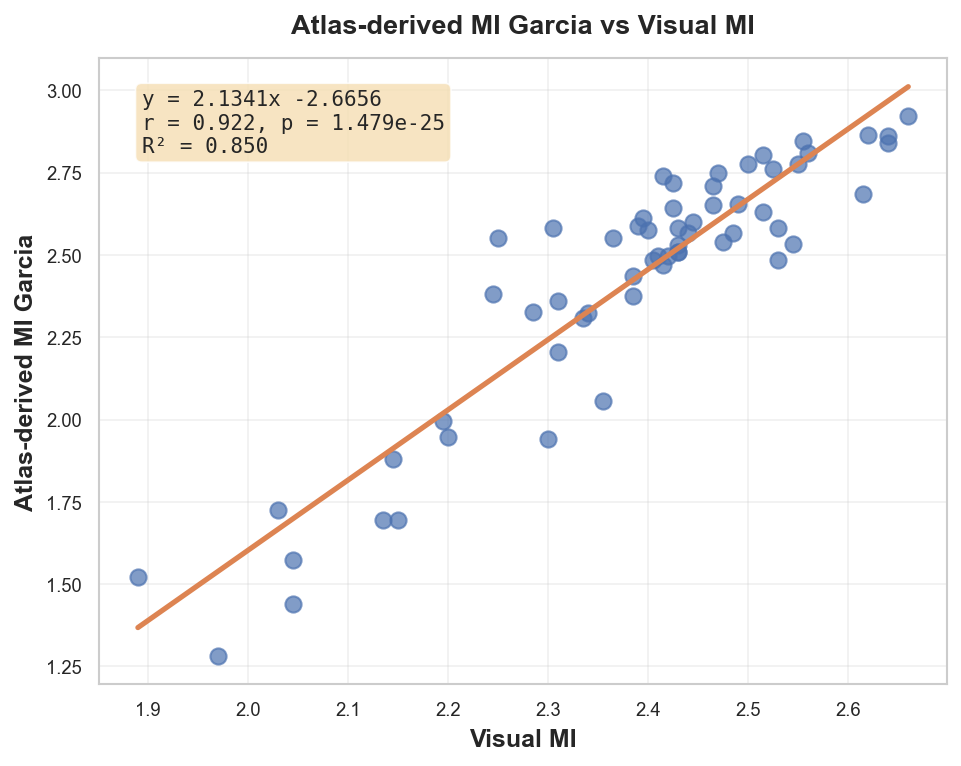

Bland-Altman MI Garcia - Visual MI
bias = +0.0380, 95% LoA = [-0.4437, 0.5198]
Shapiro-Wilk W = 0.8595, p = 5.875e-06


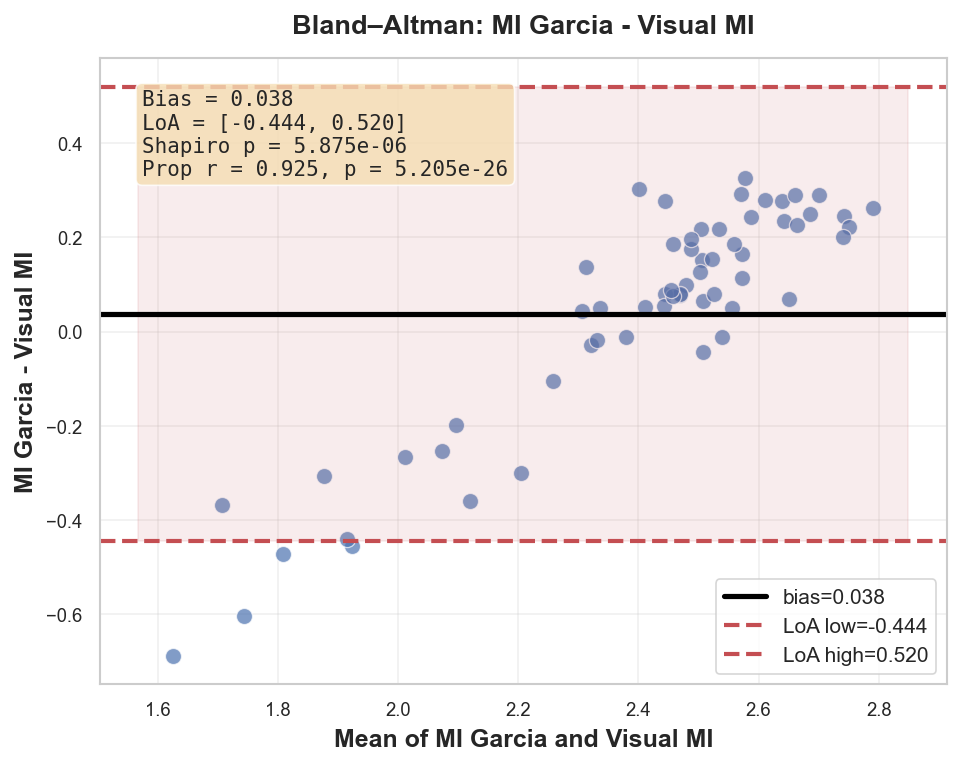

In [8]:
if {'MI_Garcia','MI_Visual'}.issubset(agg.columns):
    res_mi = regression_with_cv(agg, 'MI_Visual', 'MI_Garcia')
    print('MI Garcia ~ Visual MI')
    print(f"n = {len(res_mi['data'])}")
    print(f"Equation: y = {res_mi['slope']:.4f}x {res_mi['intercept']:+.4f}")
    print(f"Pearson r = {res_mi['r']:.4f}, p = {res_mi['p']:.3e}, R2 = {res_mi['r2']:.4f}, RMSE = {res_mi['rmse']:.4f}")
    print(f"5-fold CV R2 = {res_mi['cv_r2_mean']:.4f} ± {res_mi['cv_r2_sd']:.4f}")
    print(f"5-fold CV RMSE = {res_mi['cv_rmse_mean']:.4f} ± {res_mi['cv_rmse_sd']:.4f}")
    plot_regression(res_mi, 'MI_Visual', 'MI_Garcia', 'corr_fig2_MI_Garcia_vs_Visual_MI.pdf', 'Visual MI', 'Atlas-derived MI Garcia')

    ba_mi = bland_altman(agg['MI_Garcia'], agg['MI_Visual'])
    print('Bland-Altman MI Garcia - Visual MI')
    print(f"bias = {ba_mi['bias']:+.4f}, 95% LoA = [{ba_mi['loa_low']:.4f}, {ba_mi['loa_high']:.4f}]")
    print(f"Shapiro-Wilk W = {ba_mi['shapiro_w']:.4f}, p = {ba_mi['shapiro_p']:.3e}")
    plot_bland_altman(ba_mi, 'corr_fig5_bland_altman_MI_Garcia_vs_Visual.pdf', 'Mean of MI Garcia and Visual MI', 'MI Garcia - Visual MI')


## 8. Regression and agreement: Atlas-estimated vs measured production


Production descriptive statistics:
       Atlas_estimated_production_kg  Measured_production_kg
count                          60.00                   60.00
mean                          269.53                  677.76
std                            87.61                   93.23
min                           130.36                  500.48
25%                           206.02                  623.53
50%                           254.24                  673.93
75%                           300.50                  733.37
max                           520.63                  905.63
Measured production ~ Atlas-estimated production
n = 60
Equation: y = 1.0049x +406.9161
Pearson r = 0.9443, p = 1.130e-29, R2 = 0.8916, RMSE = 30.4332 kg
5-fold CV R2 = 0.8796 ± 0.0084
5-fold CV RMSE = 30.8445 ± 3.1885 kg


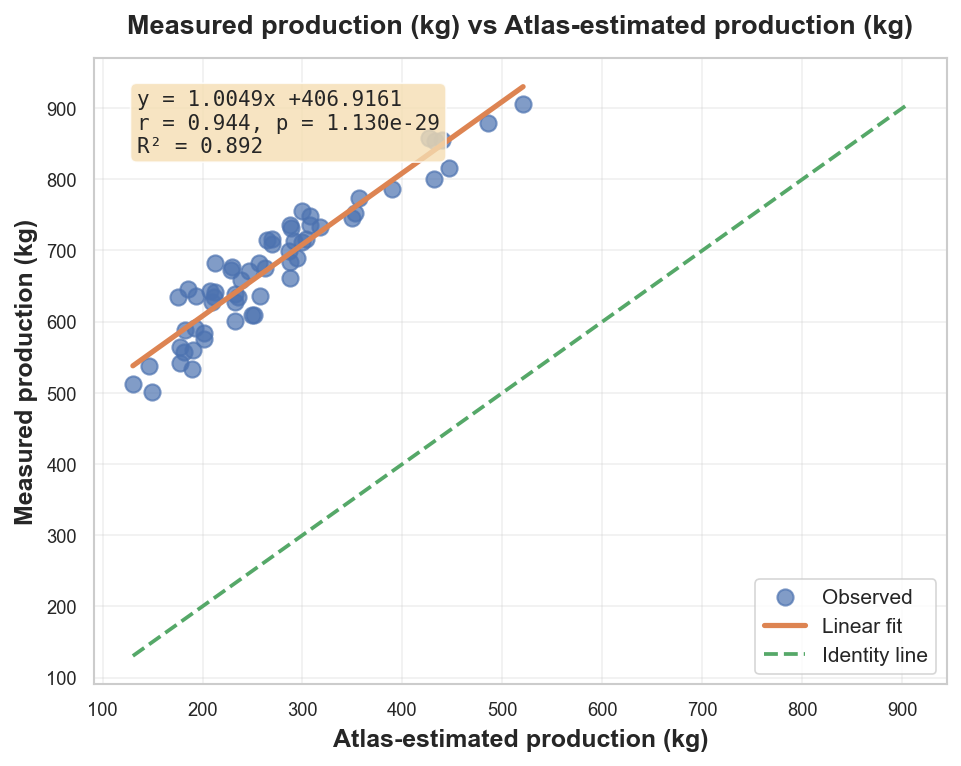

Bland-Altman measured - Atlas-estimated production
bias = +408.23 kg, 95% LoA = [348.07, 468.39] kg
Proportional bias: r = 0.1858, p = 0.1552


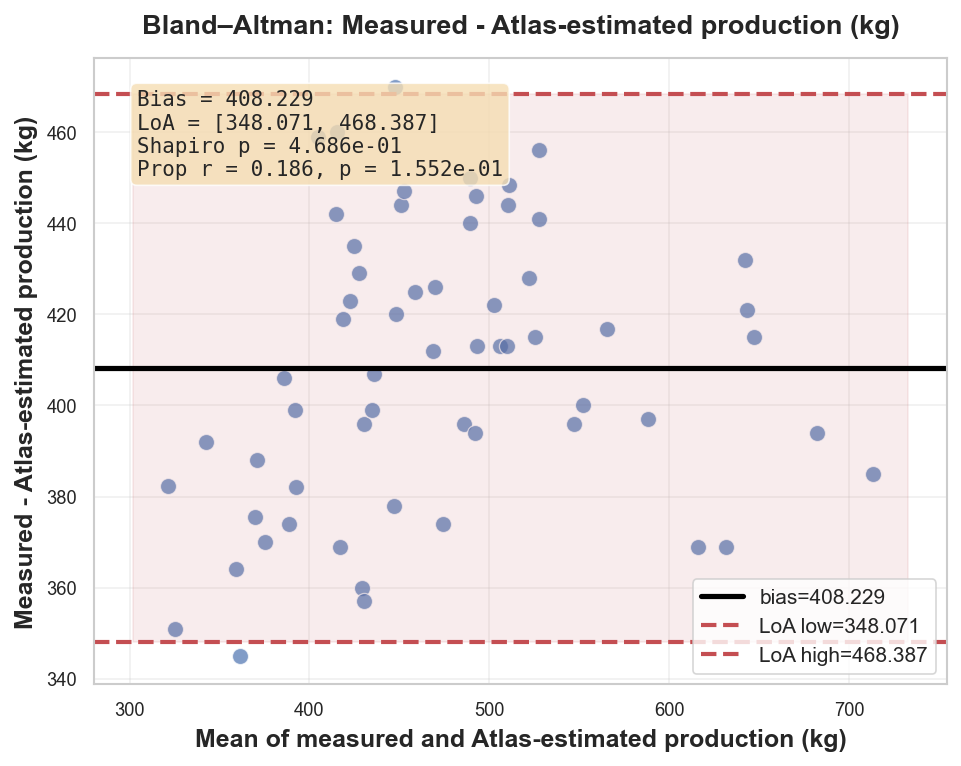

In [9]:
if {'Atlas_estimated_production_kg','Measured_production_kg'}.issubset(agg.columns):
    prod = agg[['Atlas_estimated_production_kg','Measured_production_kg']].dropna()
    print('Production descriptive statistics:')
    print(prod.describe().round(2))
    prod.describe().round(3).to_csv(TAB_DIR / 'production_descriptive_statistics.csv')

    res_prod = regression_with_cv(agg, 'Atlas_estimated_production_kg', 'Measured_production_kg')
    print('Measured production ~ Atlas-estimated production')
    print(f"n = {len(res_prod['data'])}")
    print(f"Equation: y = {res_prod['slope']:.4f}x {res_prod['intercept']:+.4f}")
    print(f"Pearson r = {res_prod['r']:.4f}, p = {res_prod['p']:.3e}, R2 = {res_prod['r2']:.4f}, RMSE = {res_prod['rmse']:.4f} kg")
    print(f"5-fold CV R2 = {res_prod['cv_r2_mean']:.4f} ± {res_prod['cv_r2_sd']:.4f}")
    print(f"5-fold CV RMSE = {res_prod['cv_rmse_mean']:.4f} ± {res_prod['cv_rmse_sd']:.4f} kg")
    plot_regression(res_prod, 'Atlas_estimated_production_kg', 'Measured_production_kg', 'corr_fig3_production_estimated_vs_measured.pdf', 'Atlas-estimated production (kg)', 'Measured production (kg)', identity=True)

    # Bias defined as measured minus estimated to quantify underestimation by Atlas.
    ba_prod = bland_altman(agg['Measured_production_kg'], agg['Atlas_estimated_production_kg'])
    print('Bland-Altman measured - Atlas-estimated production')
    print(f"bias = {ba_prod['bias']:+.2f} kg, 95% LoA = [{ba_prod['loa_low']:.2f}, {ba_prod['loa_high']:.2f}] kg")
    print(f"Proportional bias: r = {ba_prod['prop_r']:.4f}, p = {ba_prod['prop_p']:.4f}")
    plot_bland_altman(ba_prod, 'corr_fig6_bland_altman_production.pdf', 'Mean of measured and Atlas-estimated production (kg)', 'Measured - Atlas-estimated production (kg)')


## 9. Optional supplementary PCA

Use only as supplementary material. It is not essential for the paper's main claim.


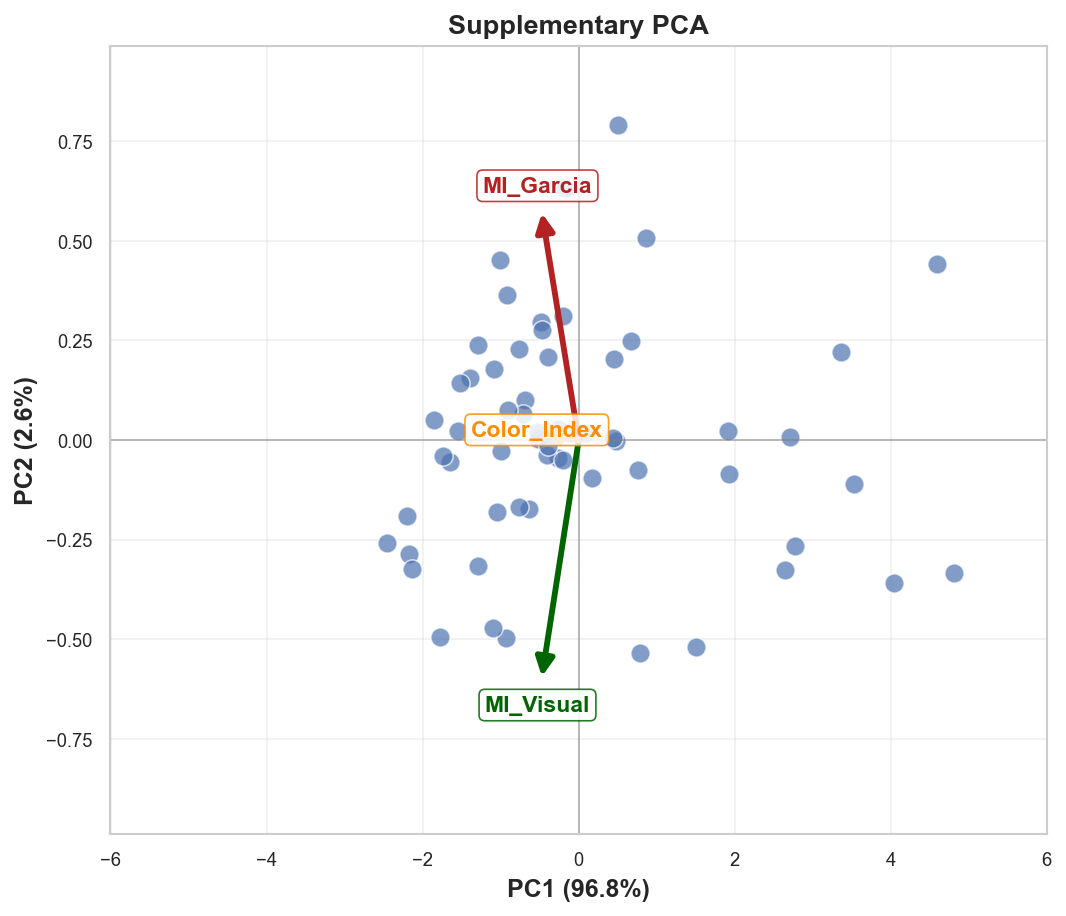

In [10]:
if {'MI_Garcia', 'MI_Visual', 'Color_Index'}.issubset(agg.columns):
    pca_vars = ['MI_Garcia', 'MI_Visual', 'Color_Index']
    pca_data = agg[pca_vars].dropna().copy()

    if len(pca_data) < 2:
        print('Not enough complete observations for PCA.')
    else:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(pca_data.values)

        pca = PCA(n_components=2)
        scores = pca.fit_transform(X_scaled)

        fig, ax = plt.subplots(figsize=(7.2, 6.2))
        sns.scatterplot(
            x=scores[:, 0],
            y=scores[:, 1],
            alpha=0.7,
            color=PALETTE[0],
            s=85,
            ax=ax,
        )

        # Better arrow display: scale loadings to the score cloud and label them clearly.
        loads = pca.components_.T
        score_span = np.max(np.abs(scores), axis=0)
        load_span = np.max(np.abs(loads), axis=0)
        load_span[load_span == 0] = 1.0
        arrow_scale = 0.75 * np.min(score_span / load_span)
        arrow_colors = ['firebrick', 'darkgreen', 'darkorange']

        for idx, (var_label, load_vec) in enumerate(zip(pca_vars, loads)):
            lx, ly = load_vec * arrow_scale
            color = arrow_colors[idx % len(arrow_colors)]

            ax.annotate(
                '',
                xy=(lx, ly),
                xytext=(0, 0),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=color,
                    lw=2.8,
                    mutation_scale=18,
                    shrinkA=0,
                    shrinkB=0,
                ),
                zorder=4,
            )

            label_x = lx * 1.12
            label_y = ly * 1.12
            ax.text(
                label_x,
                label_y,
                var_label,
                ha='center',
                va='center',
                fontsize=11,
                color=color,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=color, alpha=0.85),
                zorder=5,
            )

        # Keep the loadings and scores on the same visible canvas.
        x_lim = max(np.max(np.abs(scores[:, 0])), np.max(np.abs(loads[:, 0] * arrow_scale))) * 1.25
        y_lim = max(np.max(np.abs(scores[:, 1])), np.max(np.abs(loads[:, 1] * arrow_scale))) * 1.25
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-y_lim, y_lim)

        ax.axhline(0, color='gray', lw=1, alpha=0.5)
        ax.axvline(0, color='gray', lw=1, alpha=0.5)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)', fontsize=12, fontweight='bold')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)', fontsize=12, fontweight='bold')
        ax.set_title('Supplementary PCA', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'supplementary_pca.pdf', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print('Skipping PCA because one or more required columns are missing.')

## 10. Manuscript-ready numerical summary

Copy these values into the LaTeX file after running the notebook.


In [11]:
print('=== MANUSCRIPT SUMMARY ===')
print(f'Analytical unit: {len(agg)} subsections after aggregating two canopy faces.')
print(f'Raw side-level observations: {len(raw)}.')
print(f'Total Atlas-detected olives in aggregated dataset: {int(agg[CL_COLS].sum().sum())}.')
print('Ripening classes:')
for _, row in class_summary.iterrows():
    print(f"{row['class']}: {int(row['count'])} ({row['percent']:.1f}%)")

if 'res_mi' in globals():
    print('MI regression:')
    print(f"MI_Garcia = {res_mi['slope']:.4f} * MI_Visual {res_mi['intercept']:+.4f}; R2={res_mi['r2']:.4f}; RMSE={res_mi['rmse']:.4f}; CV R2={res_mi['cv_r2_mean']:.4f}±{res_mi['cv_r2_sd']:.4f}; CV RMSE={res_mi['cv_rmse_mean']:.4f}±{res_mi['cv_rmse_sd']:.4f}")
    print(f"MI Bland-Altman bias={ba_mi['bias']:+.4f}; LoA=[{ba_mi['loa_low']:.4f}, {ba_mi['loa_high']:.4f}]; Shapiro p={ba_mi['shapiro_p']:.3e}")

if 'res_prod' in globals():
    print('Production regression:')
    print(f"Measured = {res_prod['slope']:.4f} * Atlas_estimated {res_prod['intercept']:+.4f}; R2={res_prod['r2']:.4f}; RMSE={res_prod['rmse']:.2f}; CV R2={res_prod['cv_r2_mean']:.4f}±{res_prod['cv_r2_sd']:.4f}; CV RMSE={res_prod['cv_rmse_mean']:.2f}±{res_prod['cv_rmse_sd']:.2f}")
    print(f"Production Bland-Altman measured-estimated bias={ba_prod['bias']:+.2f} kg; LoA=[{ba_prod['loa_low']:.2f}, {ba_prod['loa_high']:.2f}] kg; proportional bias r={ba_prod['prop_r']:.4f}, p={ba_prod['prop_p']:.4f}")


=== MANUSCRIPT SUMMARY ===
Analytical unit: 60 subsections after aggregating two canopy faces.
Raw side-level observations: 120.
Total Atlas-detected olives in aggregated dataset: 17950.
Ripening classes:
CL 0: 974 (5.4%)
CL 1: 1957 (10.9%)
CL 2: 3852 (21.5%)
CL 3: 11167 (62.2%)
CL 4: 0 (0.0%)
MI regression:
MI_Garcia = 2.1341 * MI_Visual -2.6656; R2=0.8499; RMSE=0.1512; CV R2=0.7796±0.1706; CV RMSE=0.1564±0.0451
MI Bland-Altman bias=+0.0380; LoA=[-0.4437, 0.5198]; Shapiro p=5.875e-06
Production regression:
Measured = 1.0049 * Atlas_estimated +406.9161; R2=0.8916; RMSE=30.43; CV R2=0.8796±0.0084; CV RMSE=30.84±3.19
Production Bland-Altman measured-estimated bias=+408.23 kg; LoA=[348.07, 468.39] kg; proportional bias r=0.1858, p=0.1552
